In [2]:
import numpy as np
import pandas as pd

import jax
import jax.numpy as jnp
jax.config.update('jax_enable_x64', True)

from data import get_data
from models import log_stegmann_spin

from bilby.hyper.model import Model

import gwpopulation as gwpop
from gwpopulation.experimental.jax import JittedLikelihood
gwpop.set_backend("jax")

xp = gwpop.utils.xp

%matplotlib inline


/home/noah.wolfe/.conda/envs/just-for-kicks/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
events_noah, posteriors_noah, injections_noah = get_data(
    snr_thresh=10,
    far_thresh=1,
    prefer_xphm=False,
    prefer_xphm_gwtc3=True
)

if 'log_prior' in posteriors_noah:
    posteriors_noah['prior'] = xp.exp(posteriors_noah['log_prior'])
if 'log_prior' in injections_noah:
    injections_noah['prior'] = xp.exp(injections_noah['log_prior'])

# format expected by gwpop
posteriors_noah = [
    pd.DataFrame.from_dict(
        {k : v[i] for k, v in posteriors_noah.items()},
        orient='columns'
    )
    for i in range(posteriors_noah['prior'].shape[0])
]

data will be saved to/loaded from ../../data/lvk/GWTC-4-mass_1_source-mass_ratio-redshift-a_1-a_2-cos_tilt_1-cos_tilt_2/posteriors-xphm-gwtc3.h5
loading posteriors from ../../data/lvk/GWTC-4-mass_1_source-mass_ratio-redshift-a_1-a_2-cos_tilt_1-cos_tilt_2/posteriors-xphm-gwtc3.h5


In [4]:
datadir = '../../data/stegmann'
posteriors_stegmann = pd.read_pickle(f"{datadir}/gwtc4_posteriors.pkl")
injections_stegmann = pd.read_pickle(f"{datadir}/gwtc4_injections_dict.pkl")

In [5]:
ct1_steg = np.concatenate([ p['cos_tilt_1'].sample(6913, replace=False).values for p in posteriors_stegmann ])

In [15]:
ct2_steg = np.concatenate([ p['cos_tilt_2'].sample(6913, replace=False).values for p in posteriors_stegmann ])

In [6]:
ct1_noah = np.concatenate([ p['cos_tilt_1'].values for p in posteriors_noah ])

In [13]:
ct2_noah = np.concatenate([ p['cos_tilt_2'].values for p in posteriors_noah ])

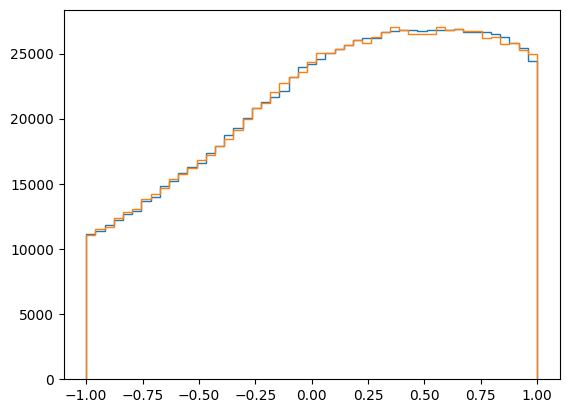

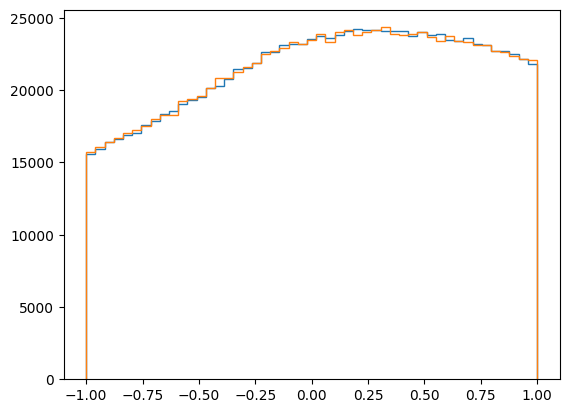

In [20]:
import matplotlib.pyplot as plt

bins = np.linspace(-1, 1, 50)

fig, ax = plt.subplots()
ax.hist(ct1_noah, bins=bins, histtype='step')
ax.hist(ct1_steg, bins=bins, histtype='step')

fig, ax = plt.subplots()
ax.hist(ct2_noah, bins=bins, histtype='step')
ax.hist(ct2_steg, bins=bins, histtype='step');

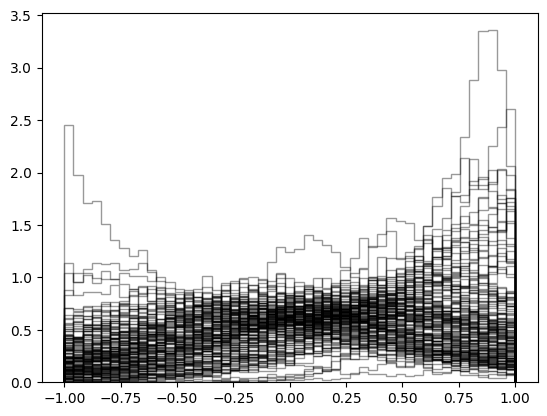

In [9]:
import matplotlib.pyplot as plt

bins = np.linspace(-1, 1, 50)

fig, ax = plt.subplots()

for p in posteriors_noah:
    ax.hist(
        p['cos_tilt_1'],
        histtype='step',
        bins=bins,
        density=True,
        color='black',
        alpha=0.4
    )


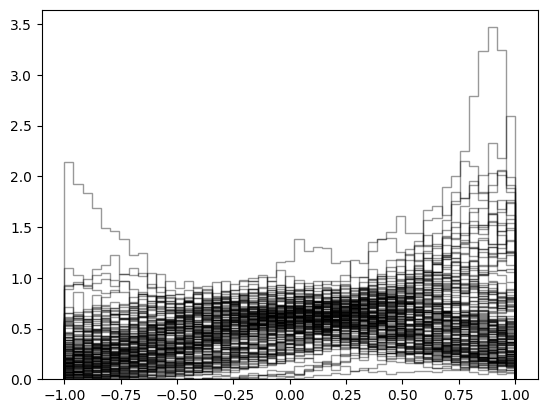

In [11]:
import matplotlib.pyplot as plt

bins = np.linspace(-1, 1, 50)

fig, ax = plt.subplots()

for p in posteriors_stegmann:
    ax.hist(
        p['cos_tilt_1'].sample(6913, replace=False),
        histtype='step',
        bins=bins,
        density=True,
        color='black',
        alpha=0.4
    )


/home/noah.wolfe/.conda/envs/just-for-kicks/lib/python3.11/site-packages/corner/core.py:126: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = pl.subplots(K, K, figsize=(dim, dim))


KeyboardInterrupt: 

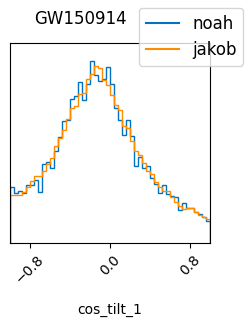

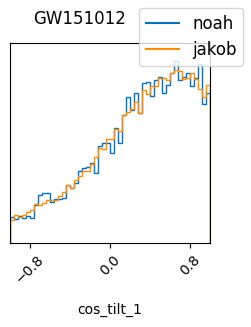

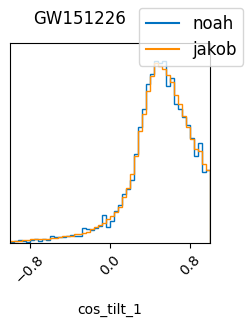

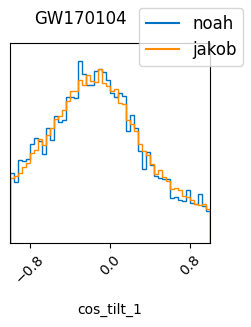

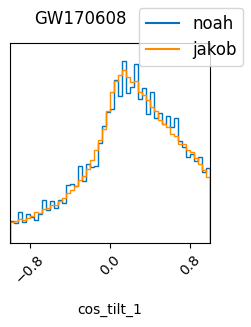

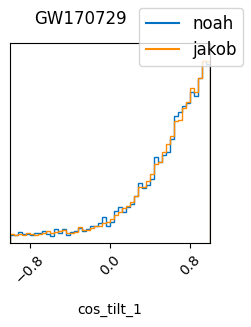

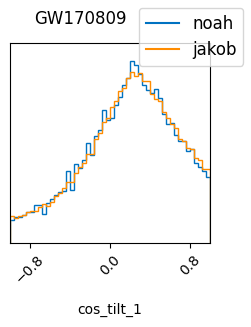

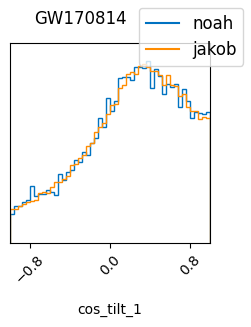

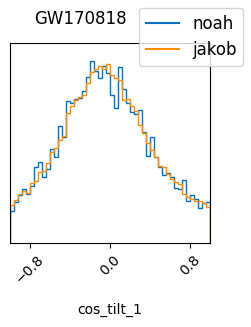

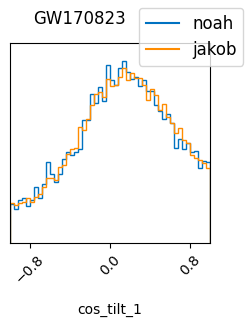

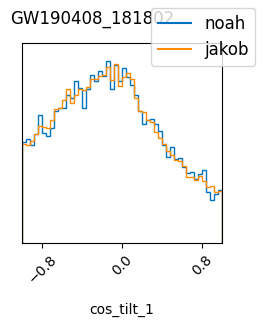

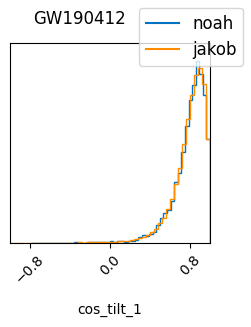

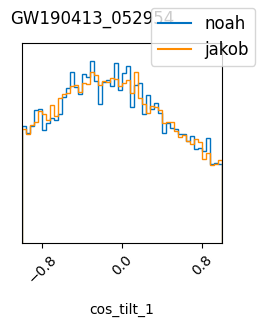

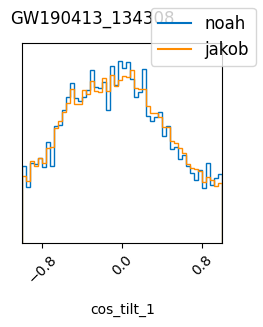

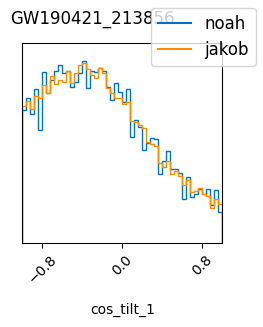

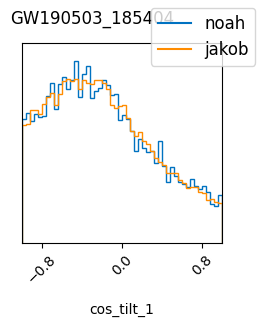

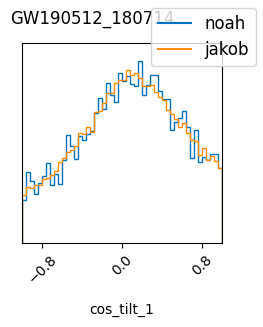

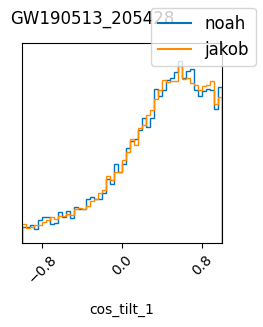

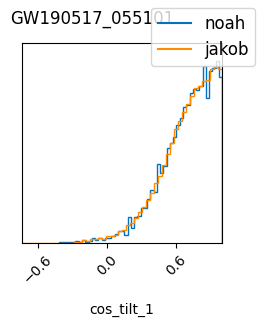

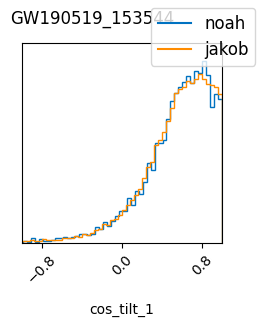

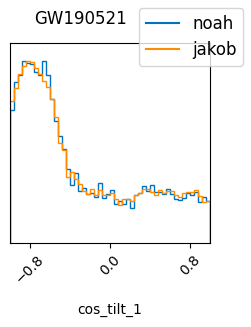

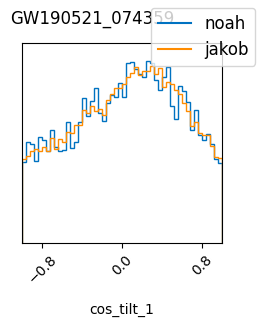

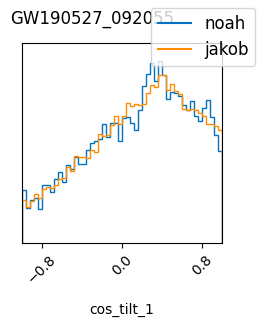

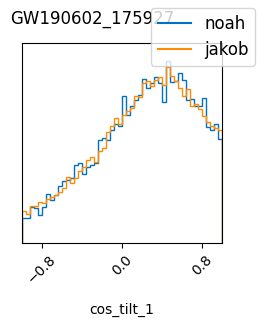

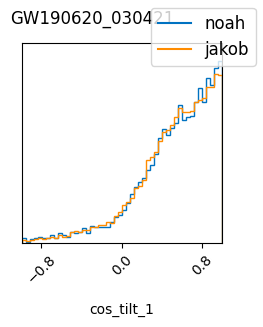

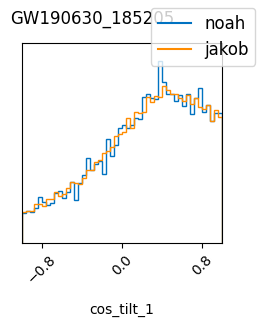

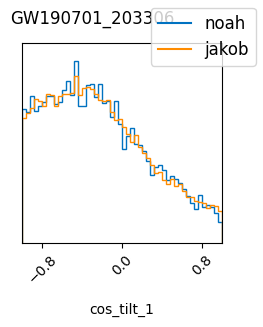

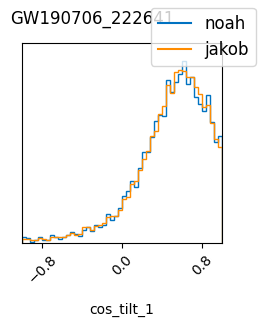

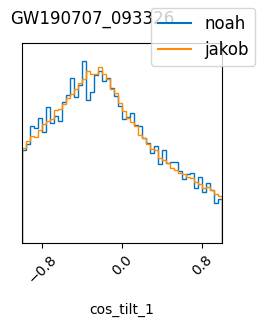

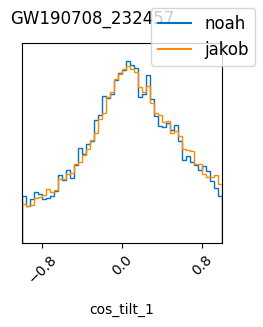

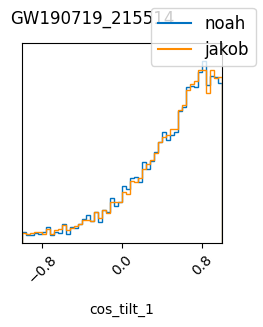

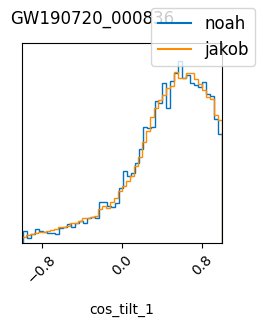

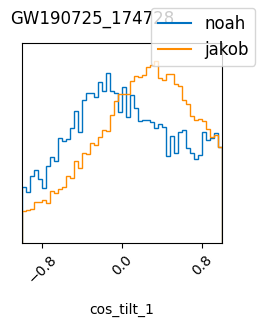

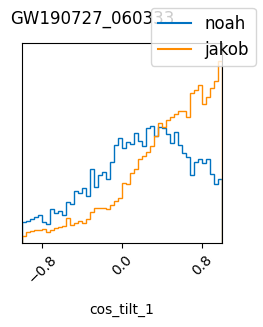

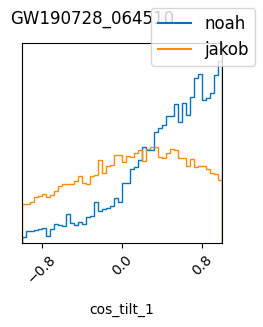

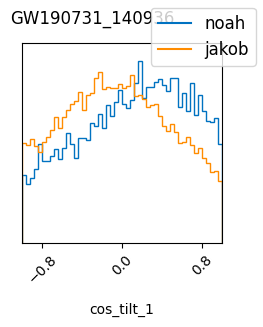

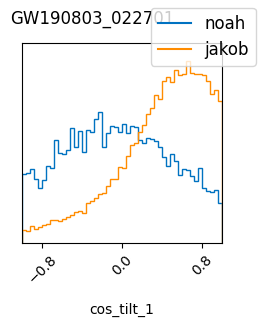

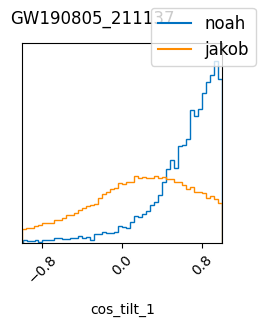

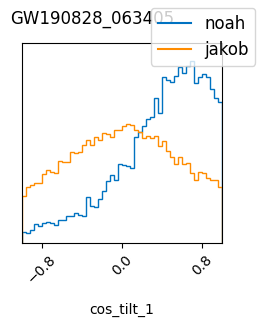

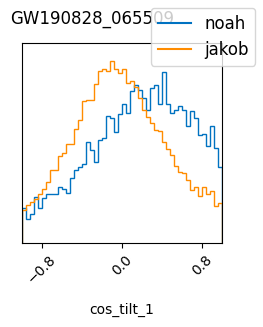

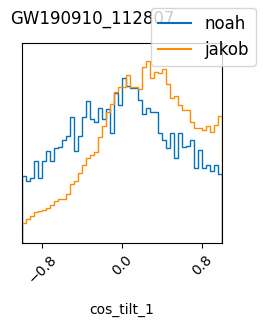

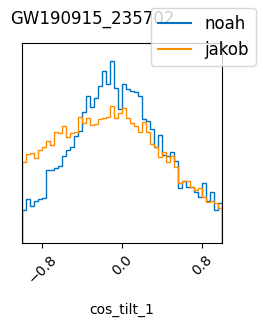

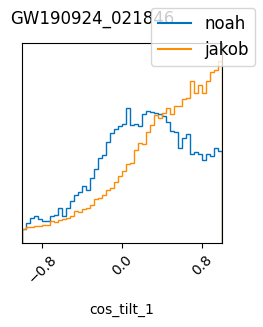

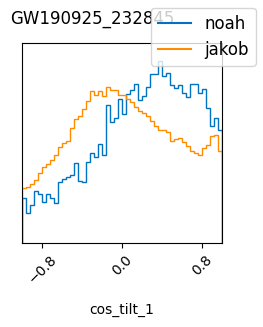

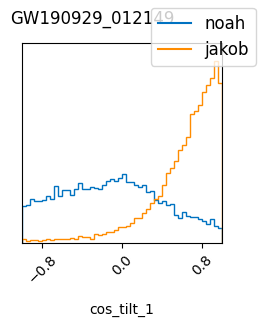

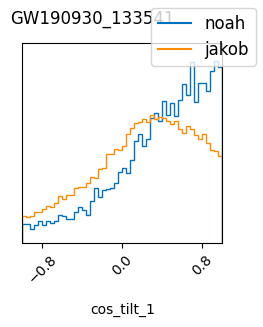

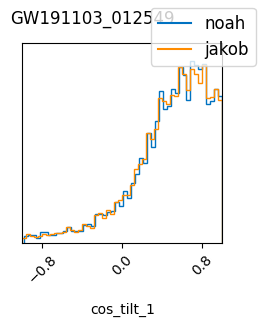

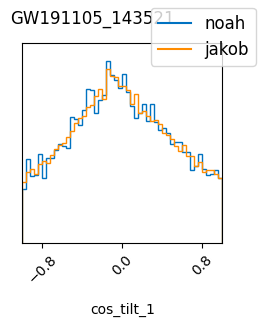

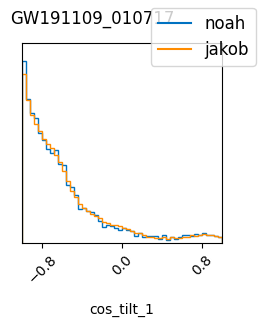

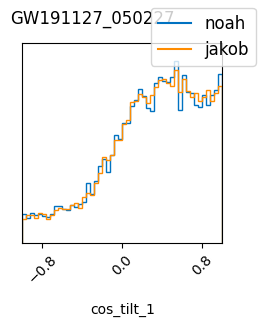

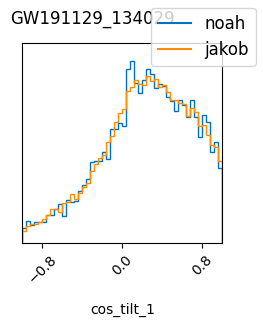

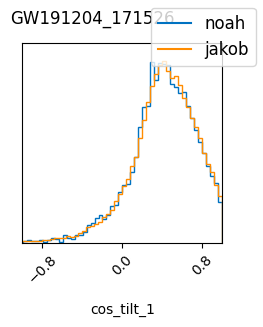

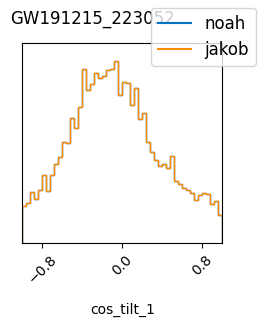

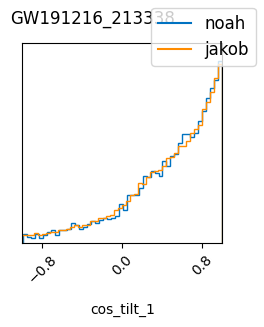

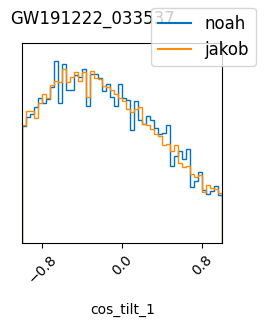

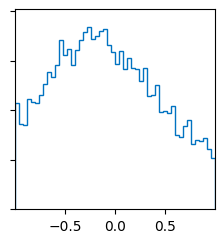

In [ ]:
from util import plot_multiple
import matplotlib.pyplot as plt

keys = ['cos_tilt_1']

for i in range(153):
    p1 = posteriors_noah[i]
    p2 = posteriors_stegmann[i]

    fig = plot_multiple(
        [
            np.column_stack([ p1[k] for k in keys ]),
            np.column_stack([ p2[k] for k in keys ])
        ],
        labels=keys,
        xs_labels=['noah', 'jakob']
    )
    fig.suptitle(events_noah[i])
    fig.savefig(f'./events/{events_noah[i]}.jpg')
    plt.close()

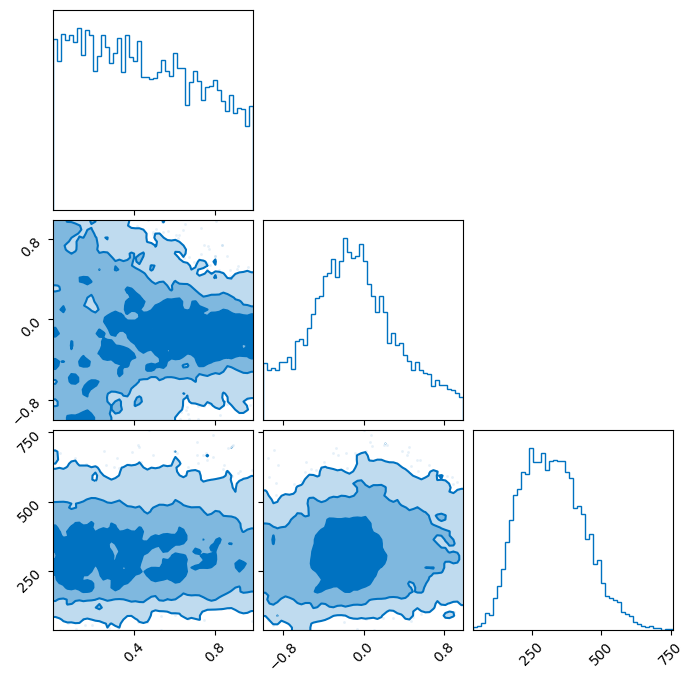

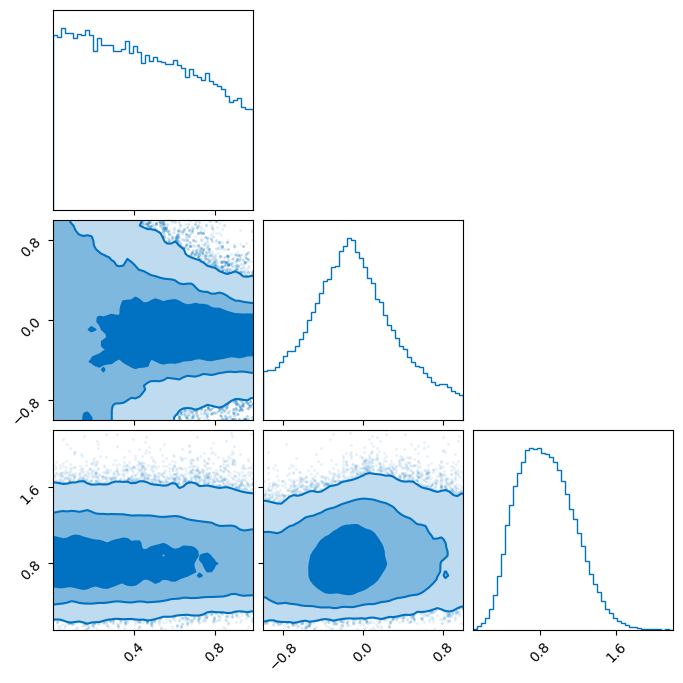

In [20]:
from util import plot_corner

fig = plot_corner(
    np.column_stack([
        #posteriors_noah[0]['mass_1'],
        #posteriors_noah[0]['mass_ratio'],
        #posteriors_noah[0]['redshift'],
        posteriors_noah[0]['a_1'],
        posteriors_noah[0]['cos_tilt_1'],
        posteriors_noah[0]['prior']
    ]),
    #labels=['mass_1', 'mass_ratio', 'prior']
)

fig = plot_corner(
    np.column_stack([
        #posteriors_stegmann[0]['mass_1'],
        #posteriors_stegmann[0]['mass_ratio'],
        #posteriors_stegmann[0]['redshift'],
        posteriors_stegmann[0]['a_1'],
        posteriors_stegmann[0]['cos_tilt_1'],
        posteriors_stegmann[0]['prior']
    ]),
    #labels=['mass_1', 'mass_ratio', 'prior']
)

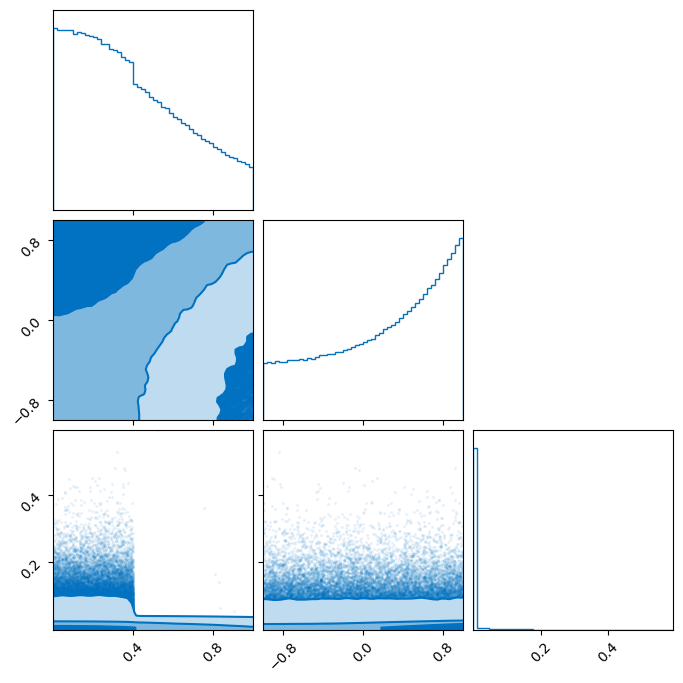

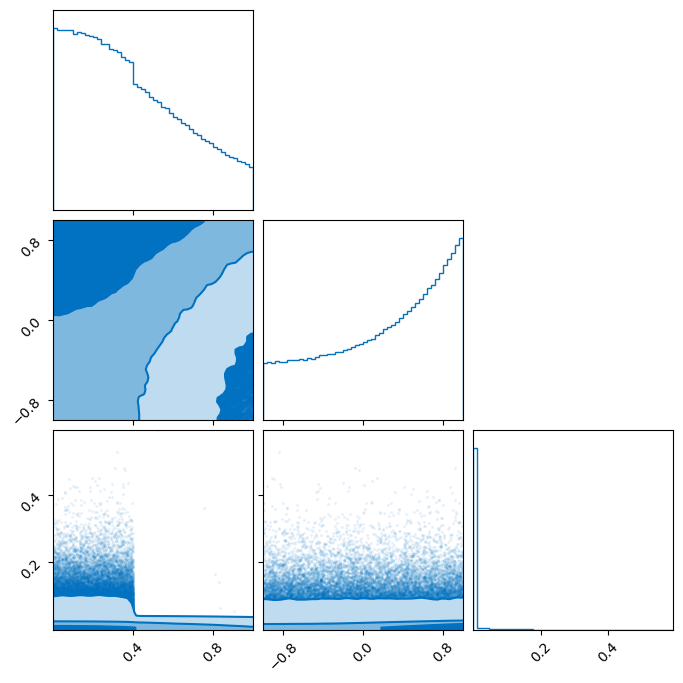

In [23]:
from util import plot_corner

fig = plot_corner(
    np.column_stack([
        #posteriors_noah[0]['mass_1'],
        #posteriors_noah[0]['mass_ratio'],
        #posteriors_noah[0]['redshift'],
        injections_noah['a_1'],
        injections_noah['cos_tilt_1'],
        injections_noah['prior']
    ]),
    #labels=['mass_1', 'mass_ratio', 'prior']
)

fig = plot_corner(
    np.column_stack([
        #posteriors_stegmann[0]['mass_1'],
        #posteriors_stegmann[0]['mass_ratio'],
        #posteriors_stegmann[0]['redshift'],
        injections_stegmann['a_1'],
        injections_stegmann['cos_tilt_1'],
        injections_stegmann['prior']
    ]),
    #labels=['mass_1', 'mass_ratio', 'prior']
)

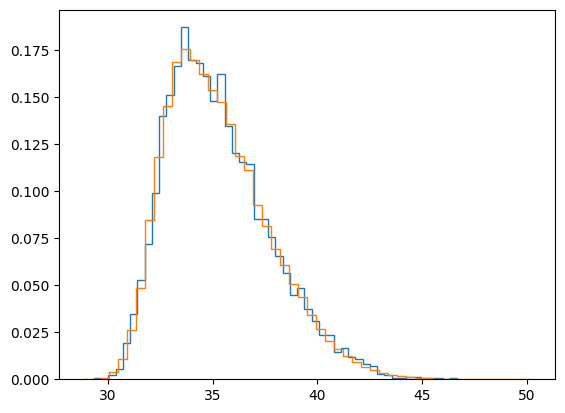

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.hist(
    posteriors_noah[0]['mass_1'],
    histtype='step',
    bins=50,
    density=True
)

ax.hist(
    posteriors_stegmann[0]['mass_1'],
    histtype='step',
    bins=50,
    density=True
);

In [7]:
import pandas as pd

datadir = '../../data/stegmann'
posteriors_stegmann = pd.read_pickle(f"{datadir}/gwtc4_posteriors.pkl")
injections_stegmann = pd.read_pickle(f"{datadir}/gwtc4_injections_dict.pkl")

In [6]:
injections_noah

{'a_1': array([0.16243093, 0.137373  , 0.02898515, ..., 0.99583277, 0.55638647,
        0.49881459], shape=(1065922,)),
 'a_2': array([0.3627992 , 0.28184632, 0.2437523 , ..., 0.95607815, 0.32076786,
        0.27731706], shape=(1065922,)),
 'cos_tilt_1': array([ 0.07403731,  0.72230954, -0.38512757, ...,  0.93889264,
         0.67981822, -0.2130991 ], shape=(1065922,)),
 'cos_tilt_2': array([ 0.71306297, -0.08572489,  0.94640479, ...,  0.88695208,
        -0.75479131, -0.3162247 ], shape=(1065922,)),
 'far': array([           inf,            inf,            inf, ...,
        6.17709212e-04, 7.18102047e-08, 2.87921015e-03], shape=(1065922,)),
 'geocent_time': array([1.13310020e+09, 1.13046871e+09, 1.12718860e+09, ...,
        1.38945323e+09, 1.38945358e+09, 1.38945488e+09], shape=(1065922,)),
 'mass_ratio': array([0.44799082, 0.81033314, 0.74996786, ..., 0.73068224, 0.66393557,
        0.85476055], shape=(1065922,)),
 'prior': Array([9.44182132e-05, 2.13199834e-04, 4.10222859e-04, ...,


In [ ]:
fig, ax = plt.subplots()

ax.hist(
    
)

In [5]:
injections_stegmann

{'mass_1': array([45.15422679, 20.46347243, 31.49269517, ..., 22.27432032,
        65.88646499,  2.25242744], shape=(1065922,)),
 'mass_ratio': array([0.44799082, 0.81033314, 0.74996786, ..., 0.73068224, 0.66393557,
        0.85476055], shape=(1065922,)),
 'a_1': array([0.16243093, 0.137373  , 0.02898515, ..., 0.99583277, 0.55638647,
        0.49881459], shape=(1065922,)),
 'a_2': array([0.3627992 , 0.28184632, 0.2437523 , ..., 0.95607815, 0.32076786,
        0.27731706], shape=(1065922,)),
 'cos_tilt_1': array([ 0.07403731,  0.72230954, -0.38512757, ...,  0.93889264,
         0.67981822, -0.2130991 ], shape=(1065922,)),
 'cos_tilt_2': array([ 0.71306297, -0.08572489,  0.94640479, ...,  0.88695208,
        -0.75479131, -0.3162247 ], shape=(1065922,)),
 'redshift': array([0.1502511 , 0.10812333, 0.183693  , ..., 0.38669392, 0.73260368,
        0.03056327], shape=(1065922,)),
 'prior': array([9.44182132e-05, 2.13199834e-04, 4.10222859e-04, ...,
        1.33253181e-05, 2.76813965e-05, 1.1

In [ ]:
def spin_model(
    which_model,
    dataset,
    mu_1,
    sigma_1,
    mu_tilt_1,
    sigma_tilt_1, 
    mu_2,
    sigma_2,
    mu_3,
    sigma_3,
    weight_a,
    m_cut
):
    # Unpack variables from dataset
    a_1 = dataset["a_1"]
    a_2 = dataset["a_2"]
    cos_tilt_1 = dataset["cos_tilt_1"]
    cos_tilt_2 = dataset["cos_tilt_2"]
    m_1 = dataset["mass_1"]

    # STEGMANN model
    if which_model == 'stegmann':
        # Free Gaussian component
        comp1 = gwpop.utils.truncnorm(a_1, mu_1, sigma_1, 1, 0) * \
                gwpop.utils.truncnorm(a_2, mu_1, sigma_1, 1, 0) * \
                gwpop.utils.truncnorm(cos_tilt_1, mu_tilt_1, sigma_tilt_1, 1, -1) * \
                gwpop.utils.truncnorm(cos_tilt_2, mu_tilt_1, sigma_tilt_1, 1, -1)

        # Isotropic component
        comp2 = gwpop.utils.truncnorm(a_1, mu_2, sigma_2, 1, 0) * \
                gwpop.utils.truncnorm(a_2, mu_2, sigma_2, 1, 0) * \
                0.5 * 0.5 
        
        # High-mass isotropic component
        comp3 = gwpop.utils.truncnorm(a_1, mu_3, sigma_3, 1, 0) * \
                gwpop.utils.truncnorm(a_2, mu_3, sigma_3, 1, 0) * \
                0.5 * 0.5 
        
        # Mass-dependent transition function
        zeta = 1 / (1 + xp.exp(-m_1+m_cut))
        
        # Combine components with mass-dependent transition
        return (1 - zeta) * (weight_a * comp1 + (1 - weight_a) * comp2) + zeta * comp3

        # NOAH model
    elif which_model == 'noah':
        return xp.exp(log_stegmann_spin(
            dataset, dict(
                mu_chi=mu_1,
                sigma_chi=sigma_1,
                mu_chi_iso=mu_2,
                sigma_chi_iso=sigma_2,
                mu_chi_high_iso=mu_3,
                sigma_chi_high_iso=sigma_3,
                mu_spin=mu_tilt_1,
                sigma_spin=sigma_tilt_1,
                xi_spin=weight_a,
                transition_mass=m_cut
            )
        ))

In [ ]:
from bilby.core.result import read_in_result
res = read_in_result('/home/noah.wolfe/projects/tilts-and-kicks/data/inference/strong/gwpop-tests/model-stegmann_data-stegmann_var-1_seed-1701/run_result.hdf5')

idx = res.posterior['log_likelihood'].argmax()
parameters = dict(res.posterior.iloc[idx])

for k, v in parameters.items():
    print(f'\t{k} : {v}')

	alpha : 2.9215863380784617
	beta : 1.9854212815993098
	gaussian_mass_maximum : 100.0
	lam : 0.013482742137413094
	lamb : 2.788678198764854
	log_likelihood : -702.1382934633414
	log_prior : -20.55020385275637
	m_cut : 41.256422991414745
	mmax : 99.13146413977837
	mmin : 2.4274132435027544
	mpp : 33.106040779394306
	mu_1 : 0.1879218419722882
	mu_2 : 0.4489694090046249
	mu_3 : 0.9196612340830346
	mu_tilt_1 : 0.24969402299621368
	sigma_1 : 0.13533192458244653
	sigma_2 : 0.5401778343294126
	sigma_3 : 0.31502397758476025
	sigma_tilt_1 : 0.7623464206533996
	sigpp : 3.649289593272638
	weight_a : 0.9546555573104236


In [ ]:
maximum_uncertainty = 1

def _noah_spin_model(
    dataset,
    mu_1,
    sigma_1,
    mu_tilt_1,
    sigma_tilt_1, 
    mu_2,
    sigma_2,
    mu_3,
    sigma_3,
    weight_a,
    m_cut
):
    return spin_model(
        'noah',
        dataset,
        mu_1,
        sigma_1,
        mu_tilt_1,
        sigma_tilt_1, 
        mu_2,
        sigma_2,
        mu_3,
        sigma_3,
        weight_a,
        m_cut
    )

model = Model(
    model_functions=[
        gwpop.models.mass.two_component_primary_mass_ratio,
        _noah_spin_model,
        gwpop.models.redshift.PowerLawRedshift(cosmo_model="Planck15"),
    ],
    cache=False,
)

vt = gwpop.vt.ResamplingVT(model=model, data=injections_noah, n_events=len(posteriors_noah))

# set random state for re-sampling the single-event PE
np.random.seed(42)

likelihood = gwpop.hyperpe.HyperparameterLikelihood(
    posteriors=posteriors_noah,
    hyper_prior=model,
    selection_function=vt,
    maximum_uncertainty=maximum_uncertainty,
)

likelihood.log_likelihood_ratio(parameters)

Array(-1025.43095543, dtype=float64)

In [ ]:
maximum_uncertainty = 1 

def _stegmann_spin_model(
    dataset,
    mu_1,
    sigma_1,
    mu_tilt_1,
    sigma_tilt_1, 
    mu_2,
    sigma_2,
    mu_3,
    sigma_3,
    weight_a,
    m_cut
):
    return spin_model(
        'stegmann',
        dataset,
        mu_1,
        sigma_1,
        mu_tilt_1,
        sigma_tilt_1, 
        mu_2,
        sigma_2,
        mu_3,
        sigma_3,
        weight_a,
        m_cut
    )

model = Model(
    model_functions=[
        gwpop.models.mass.two_component_primary_mass_ratio,
        _stegmann_spin_model,
        gwpop.models.redshift.PowerLawRedshift(cosmo_model="Planck15"),
    ],
    cache=False,
)

vt = gwpop.vt.ResamplingVT(model=model, data=injections_stegmann, n_events=len(posteriors_stegmann))

# set random state for re-sampling the single-event PE
np.random.seed(42)

likelihood = gwpop.hyperpe.HyperparameterLikelihood(
    posteriors=posteriors_stegmann,
    hyper_prior=model,
    selection_function=vt,
    maximum_uncertainty=maximum_uncertainty,
)

likelihood.log_likelihood_ratio(parameters)

Array(-703.66369693, dtype=float64)

In [ ]:
maximum_uncertainty = 1

model = Model(
    model_functions=[
        gwpop.models.mass.two_component_primary_mass_ratio,
        _noah_spin_model,
        gwpop.models.redshift.PowerLawRedshift(cosmo_model="Planck15"),
    ],
    cache=False,
)

vt = gwpop.vt.ResamplingVT(model=model, data=injections_stegmann, n_events=len(posteriors_stegmann))

# set random state for re-sampling the single-event PE
np.random.seed(42)

likelihood = gwpop.hyperpe.HyperparameterLikelihood(
    posteriors=posteriors_stegmann,
    hyper_prior=model,
    selection_function=vt,
    maximum_uncertainty=maximum_uncertainty,
)

likelihood.log_likelihood_ratio(parameters)

Array(-703.66369693, dtype=float64)

In [ ]:
maximum_uncertainty = 1

model = Model(
    model_functions=[
        gwpop.models.mass.two_component_primary_mass_ratio,
        _stegmann_spin_model,
        gwpop.models.redshift.PowerLawRedshift(cosmo_model="Planck15"),
    ],
    cache=False,
)

vt = gwpop.vt.ResamplingVT(model=model, data=injections_noah, n_events=len(posteriors_noah))

# set random state for re-sampling the single-event PE
np.random.seed(42)

likelihood = gwpop.hyperpe.HyperparameterLikelihood(
    posteriors=posteriors_noah,
    hyper_prior=model,
    selection_function=vt,
    maximum_uncertainty=maximum_uncertainty,
)

likelihood.log_likelihood_ratio(parameters)

Array(-1025.43095543, dtype=float64)

In [ ]:
maximum_uncertainty = 1

model = Model(
    model_functions=[
        gwpop.models.mass.two_component_primary_mass_ratio,
        _noah_spin_model,
        gwpop.models.redshift.PowerLawRedshift(cosmo_model="Planck15"),
    ],
    cache=False,
)

vt = gwpop.vt.ResamplingVT(model=model, data=injections_stegmann, n_events=len(posteriors_stegmann))

# set random state for re-sampling the single-event PE
np.random.seed(1701)

likelihood = gwpop.hyperpe.HyperparameterLikelihood(
    posteriors=posteriors_stegmann,
    hyper_prior=model,
    selection_function=vt,
    maximum_uncertainty=maximum_uncertainty,
)

likelihood.log_likelihood_ratio(parameters)

Array(-703.50242427, dtype=float64)